# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
import sys
sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from pathlib import Path
import os

data_dir = Path.home()/ "Desktop/mlp_coursework1/mlpractical/data"
os.environ["MLP_DATA_DIR"] = str(data_dir)

print("MLP_DATA_DIR =", os.environ["MLP_DATA_DIR"])
print("train exists:", (data_dir/"emnist-train.npz").is_file())
print("valid exists:", (data_dir/"emnist-valid.npz").is_file())
print("test  exists:", (data_dir/"emnist-test.npz").is_file())


MLP_DATA_DIR = /Users/sunshanminsmacbook/Desktop/mlp_coursework1/mlpractical/data
train exists: True
valid exists: True
test  exists: True


In [2]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [3]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile '/Users/sunshanminsmacbook/Desktop/mlp_coursework1/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/sunshanminsmacbook/Desktop/mlp_coursework1/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.0s to complete
    error(train)=7.72e-01, acc(train)=7.60e-01, error(valid)=7.87e-01, acc(valid)=7.58e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 3: 1.2s to complete
    error(train)=5.02e-01, acc(train)=8.36e-01, error(valid)=5.56e-01, acc(valid)=8.19e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 1.1s to complete
    error(train)=4.68e-01, acc(train)=8.43e-01, error(valid)=5.45e-01, acc(valid)=8.22e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 1.1s to complete
    error(train)=4.46e-01, acc(train)=8.42e-01, error(valid)=5.39e-01, acc(valid)=8.17e-01


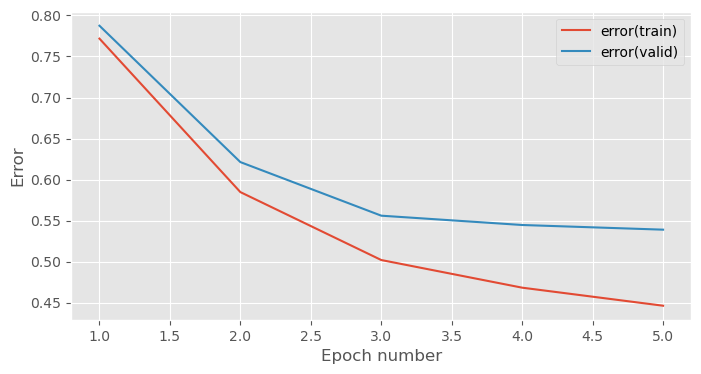

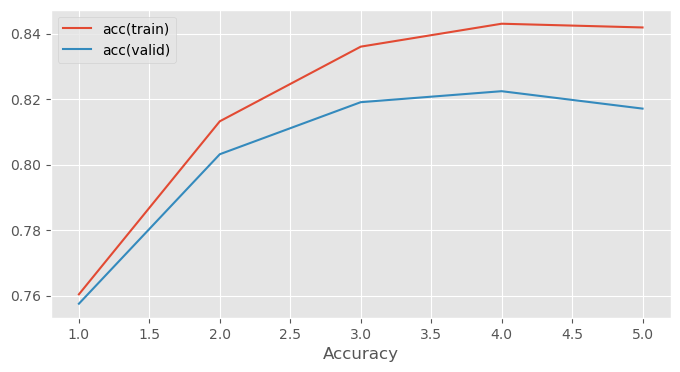

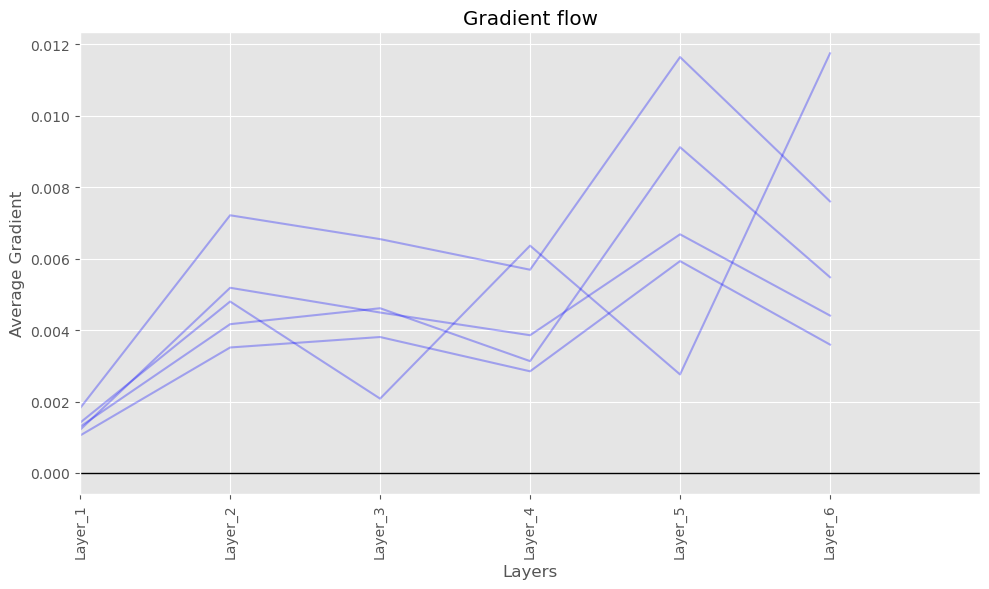

In [4]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [16]:
# ===== Width overlay (32/64/128) — match the screenshot style =====
import os
import numpy as np
import matplotlib.pyplot as plt

# -------- paths & settings --------
INDIR = "runs/width"        # 你的宽度实验 npz 保存目录（改成你的实际目录）
WIDTHS = (32, 64, 128)      # 宽度列表
ACC_OUT  = "width_all_acc.pdf"
LOSS_OUT = "width_all_loss.pdf"

# -------- exact colors (hex) --------
# train（实线）：红 / 蓝 / 淡紫   ;   valid（虚线）：灰 / 金(橄榄) / 绿
TRAIN_COLOR = {32: "#d62728", 64: "#1f77b4", 128: "#9467bd"}
VALID_COLOR = {32: "#7f7f7f", 64: "#bcbd22", 128: "#2ca02c"}

# -------- styling: mimic the screenshot --------
plt.rcParams.update({
    "figure.facecolor": "white",   # 外层白底
    "axes.facecolor":  "#EAEAEA",  # 面板浅灰背景
    "axes.edgecolor":  "#EAEAEA",
    "axes.grid":       True,
    "grid.color":      "white",
    "grid.linewidth":  1.0,
    "grid.alpha":      1.0,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon":  True,
})

# -------- loader: support both npz formats --------
def load_npz_any(path):
    """
    标准化输出:
      dict(
        train_acc, valid_acc, train_loss, valid_loss  # 1D ndarray
      )
    兼容：
      1) 新格式: acc_train/acc_valid/err_train/err_valid
      2) 旧格式: stats + keys
    """
    Z = np.load(path, allow_pickle=True)
    keys = set(Z.files)

    if {"acc_train","acc_valid","err_train","err_valid"} <= keys:
        acc_tr = np.asarray(Z["acc_train"], float)
        acc_va = np.asarray(Z["acc_valid"], float)
        err_tr = np.asarray(Z["err_train"], float)
        err_va = np.asarray(Z["err_valid"], float)
    elif {"stats","keys"} <= keys:
        stats = np.asarray(Z["stats"])
        rawk  = np.asarray(Z["keys"])
        K = list(rawk) if rawk.ndim>0 else list(rawk.item())
        def pick(name_like):
            t = name_like.replace(" ","").lower()
            for i,k in enumerate(K):
                if t in str(k).replace(" ","").lower():
                    return np.atleast_1d(stats[i]).astype(float)
            raise KeyError(f"{name_like} not in {K}")
        acc_tr, acc_va = pick("acc(train)"),  pick("acc(valid)")
        err_tr, err_va = pick("error(train)"), pick("error(valid)")
    else:
        raise ValueError(f"Unrecognized npz format: {path} -> {keys}")

    # 若 accuracy 是百分比（>1），归一化回 0~1
    if max(float(acc_tr.max()), float(acc_va.max())) > 1.01:
        acc_tr, acc_va = acc_tr/100.0, acc_va/100.0

    return dict(train_acc=acc_tr, valid_acc=acc_va,
                train_loss=err_tr,  valid_loss=err_va)

# -------- read 3 files & consistency check --------
curves = {}
for w in WIDTHS:
    fn = os.path.join(INDIR, f"width_{w}_stats.npz")
    if not os.path.exists(fn):
        raise FileNotFoundError(f"缺少 {fn}，请先保存宽度 {w} 的训练结果。")
    curves[w] = load_npz_any(fn)

lengths = {w: len(curves[w]["train_acc"]) for w in WIDTHS}
if len(set(lengths.values())) != 1:
    raise ValueError(f"曲线长度不一致：{lengths}。请保存时使用 num_epochs=100 且 stats_interval=1。")
E = next(iter(lengths.values()))

# -------- plotting helpers --------
def plot_width_overlay(kind, ylabel, outfile):
    """
    kind: 'acc' 或 'loss'
    ylabel: 'Accuracy' 或 'Error'
    """
    # 尺寸近似你发的截图（宽一些，矮一点）
    fig, ax = plt.subplots(figsize=(5.1, 2.5), dpi=120)

    handles = []
    # 先画三条 train（实线）
    for w in WIDTHS:
        y = curves[w]["train_acc"] if kind=="acc" else curves[w]["train_loss"]
        (h,) = ax.plot(y, color=TRAIN_COLOR[w], linestyle="-", linewidth=2,
                       label=f"width {w}(train)")
        handles.append(h)

    # 再画三条 valid（虚线）
    for w in WIDTHS:
        y = curves[w]["valid_acc"] if kind=="acc" else curves[w]["valid_loss"]
        (h,) = ax.plot(y, color=VALID_COLOR[w], linestyle="--", linewidth=2,
                       label=f"width {w}(valid)")
        handles.append(h)

    ax.set_xlabel("Epoch number")
    ax.set_ylabel(ylabel)
    if kind == "acc":
        ax.set_ylim(0, 1)

    # 右上角图例（与示图一致）
    leg = ax.legend(handles=handles, loc="upper right", framealpha=0.9)
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_edgecolor("#DDDDDD")

    fig.tight_layout()
    fig.savefig(outfile, dpi=300)
    plt.close(fig)
    print("Saved:", os.path.abspath(outfile))

# -------- make both figures --------
plot_width_overlay("acc",  "Accuracy", ACC_OUT)
plot_width_overlay("loss", "Error",    LOSS_OUT)


Saved: /Users/sunshanminsmacbook/Desktop/mlp_coursework1/mlpractical/notebooks/width_all_acc.pdf
Saved: /Users/sunshanminsmacbook/Desktop/mlp_coursework1/mlpractical/notebooks/width_all_loss.pdf


In [21]:
# ===== Width overlay (32/64/128) — screenshot-like style =====
import os
import numpy as np
import matplotlib.pyplot as plt

# -------- paths & settings --------
INDIR = "runs/width"          # 改成你保存 npz 的目录
WIDTHS = (32, 64, 128)
ACC_OUT  = "width_all_acc.pdf"
LOSS_OUT = "width_all_loss.pdf"

# -------- exact colors (hex) --------
TRAIN_COLOR = {32: "#d62728", 64: "#1f77b4", 128: "#9467bd"}  # train: 红/蓝/淡紫（实线）
VALID_COLOR = {32: "#7f7f7f", 64: "#bcbd22", 128: "#2ca02c"}  # valid: 灰/金/绿（虚线）

# -------- style: match the example --------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":  "#EAEAEA",   # 浅灰轴背景
    "axes.edgecolor":  "#EAEAEA",
    "axes.grid":       True,
    "grid.color":      "white",
    "grid.linewidth":  1.0,
    "grid.alpha":      1.0,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# -------- loader: support new (acc_train/...) and old (stats+keys) npz --------
def load_npz_any(path):
    Z = np.load(path, allow_pickle=True)
    keys = set(Z.files)
    if {"acc_train","acc_valid","err_train","err_valid"} <= keys:
        acc_tr = np.asarray(Z["acc_train"], float)
        acc_va = np.asarray(Z["acc_valid"], float)
        err_tr = np.asarray(Z["err_train"], float)
        err_va = np.asarray(Z["err_valid"], float)
    elif {"stats","keys"} <= keys:
        stats = np.asarray(Z["stats"])
        rawk  = np.asarray(Z["keys"])
        K = list(rawk) if rawk.ndim>0 else list(rawk.item())
        def pick(name_like):
            t = name_like.replace(" ","").lower()
            for i,k in enumerate(K):
                if t in str(k).replace(" ","").lower():
                    return np.atleast_1d(stats[i]).astype(float)
            raise KeyError(name_like)
        acc_tr, acc_va = pick("acc(train)"),  pick("acc(valid)")
        err_tr, err_va = pick("error(train)"), pick("error(valid)")
    else:
        raise ValueError(f"Unrecognized npz format: {path} -> {keys}")

    # 若 accuracy 是百分比，归一化回 0~1
    if max(float(acc_tr.max()), float(acc_va.max())) > 1.01:
        acc_tr, acc_va = acc_tr/100.0, acc_va/100.0

    return dict(train_acc=acc_tr, valid_acc=acc_va,
                train_loss=err_tr,  valid_loss=err_va)

# -------- read curves & check lengths --------
curves = {}
for w in WIDTHS:
    fn = os.path.join(INDIR, f"width_{w}_stats.npz")
    if not os.path.exists(fn):
        raise FileNotFoundError(f"缺少 {fn}，请先保存宽度 {w} 的训练结果。")
    curves[w] = load_npz_any(fn)

lens = {w: len(curves[w]["train_acc"]) for w in WIDTHS}
if len(set(lens.values())) != 1:
    raise ValueError(f"曲线长度不一致：{lens}。请保存时使用 num_epochs=100 且 stats_interval=1。")

# -------- plotting (screenshot-like aspect) --------
def plot_width_overlay(kind, ylabel, outfile):
    # 例子比例：宽 5.1 in × 高 2.5 in；右上角图例
    fig, ax = plt.subplots(figsize=(6.5, 3.6), dpi=180)

    handles = []
    # train（实线）
    for w in WIDTHS:
        y = curves[w]["train_acc"] if kind=="acc" else curves[w]["train_loss"]
        (h,) = ax.plot(y, color=TRAIN_COLOR[w], linestyle="-", linewidth=2,
                       label=f"width {w}(train)")
        handles.append(h)
    # valid（虚线）
    for w in WIDTHS:
        y = curves[w]["valid_acc"] if kind=="acc" else curves[w]["valid_loss"]
        (h,) = ax.plot(y, color=VALID_COLOR[w], linestyle="--", linewidth=2,
                       label=f"width {w}(valid)")
        handles.append(h)

    ax.set_xlabel("Epoch number")
    ax.set_ylabel(ylabel)
    if kind == "acc":
        ax.set_ylim(0, 1)

    # 右上角图例，轻微半透明白底
    leg = ax.legend(handles=handles, loc="upper right", framealpha=0.8, fontsize=7)
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_edgecolor("#DDDDDD")

    fig.tight_layout()
    fig.savefig(outfile, dpi=300)
    plt.close(fig)
    print("Saved:", os.path.abspath(outfile))

# -------- make both figures --------
plot_width_overlay("acc",  "Accuracy", ACC_OUT)
plot_width_overlay("loss", "Error",    LOSS_OUT)


Saved: /Users/sunshanminsmacbook/Desktop/mlp_coursework1/mlpractical/notebooks/width_all_acc.pdf
Saved: /Users/sunshanminsmacbook/Desktop/mlp_coursework1/mlpractical/notebooks/width_all_loss.pdf


Saved: /Users/sunshanminsmacbook/Desktop/mlp_coursework1/mlpractical/notebooks/width_all_acc.pdf


AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.

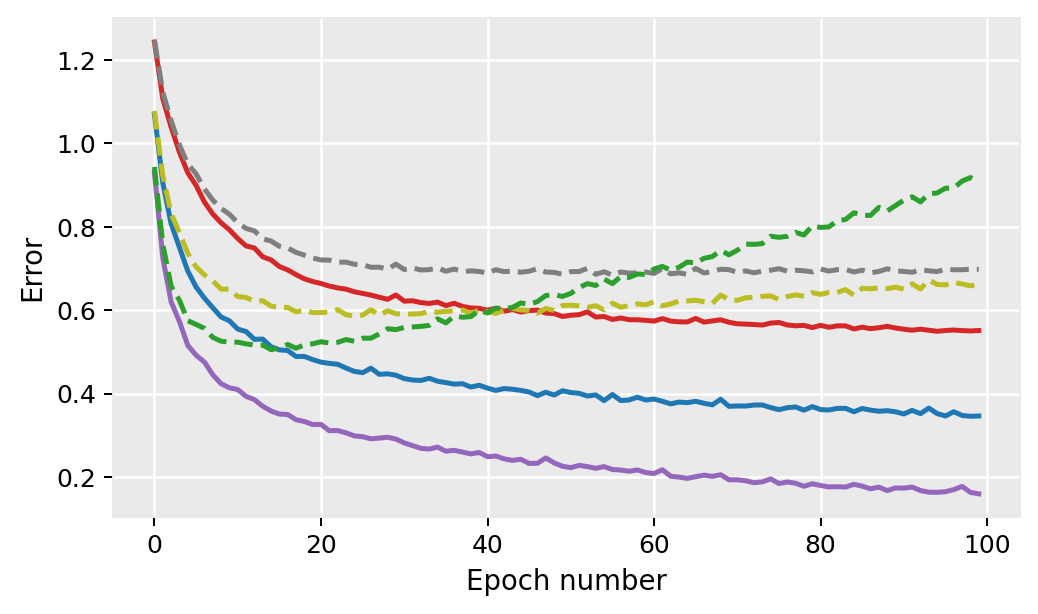

In [18]:
# ===== Width overlay (32/64/128) — taller aspect + legend outside =====
import os
import numpy as np
import matplotlib.pyplot as plt

# -------- paths & settings --------
INDIR = "runs/width"          # 改成你的 npz 目录
WIDTHS = (32, 64, 128)
ACC_OUT  = "width_all_acc.pdf"
LOSS_OUT = "width_all_loss.pdf"

# -------- exact colors (hex) --------
TRAIN_COLOR = {32: "#d62728", 64: "#1f77b4", 128: "#9467bd"}  # train: 红/蓝/淡紫（实线）
VALID_COLOR = {32: "#7f7f7f", 64: "#bcbd22", 128: "#2ca02c"}  # valid: 灰/金/绿（虚线）

# -------- style: light gray axes + white grid --------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":  "#EAEAEA",
    "axes.edgecolor":  "#EAEAEA",
    "axes.grid":       True,
    "grid.color":      "white",
    "grid.linewidth":  1.0,
    "grid.alpha":      1.0,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# -------- loader: support new (acc_train/...) and old (stats+keys) npz --------
def load_npz_any(path):
    Z = np.load(path, allow_pickle=True)
    keys = set(Z.files)
    if {"acc_train","acc_valid","err_train","err_valid"} <= keys:
        acc_tr = np.asarray(Z["acc_train"], float)
        acc_va = np.asarray(Z["acc_valid"], float)
        err_tr = np.asarray(Z["err_train"], float)
        err_va = np.asarray(Z["err_valid"], float)
    elif {"stats","keys"} <= keys:
        stats = np.asarray(Z["stats"])
        rawk  = np.asarray(Z["keys"])
        K = list(rawk) if rawk.ndim>0 else list(rawk.item())
        def pick(name_like):
            t = name_like.replace(" ","").lower()
            for i,k in enumerate(K):
                if t in str(k).replace(" ","").lower():
                    return np.atleast_1d(stats[i]).astype(float)
            raise KeyError(name_like)
        acc_tr, acc_va = pick("acc(train)"),  pick("acc(valid)")
        err_tr, err_va = pick("error(train)"), pick("error(valid)")
    else:
        raise ValueError(f"Unrecognized npz format: {path} -> {keys}")

    # 若 accuracy 是百分比（>1），归一化回 0~1
    if max(float(acc_tr.max()), float(acc_va.max())) > 1.01:
        acc_tr, acc_va = acc_tr/100.0, acc_va/100.0

    return dict(train_acc=acc_tr, valid_acc=acc_va,
                train_loss=err_tr,  valid_loss=err_va)

# -------- read curves & check lengths --------
curves = {}
for w in WIDTHS:
    fn = os.path.join(INDIR, f"width_{w}_stats.npz")
    if not os.path.exists(fn):
        raise FileNotFoundError(f"缺少 {fn}，请先保存宽度 {w} 的训练结果。")
    curves[w] = load_npz_any(fn)

lens = {w: len(curves[w]["train_acc"]) for w in WIDTHS}
if len(set(lens.values())) != 1:
    raise ValueError(f"曲线长度不一致：{lens}。请保存时使用 num_epochs=100 且 stats_interval=1。")

# -------- plotting: taller aspect + legend outside --------
def plot_width_overlay(kind, ylabel, outfile):
    # 更舒服的长宽比 + 更清晰的分辨率
    fig, ax = plt.subplots(figsize=(6.5, 3.6), dpi=180)

    handles = []
    # 先画 train（实线）
    for w in WIDTHS:
        y = curves[w]["train_acc"] if kind=="acc" else curves[w]["train_loss"]
        (h,) = ax.plot(y, color=TRAIN_COLOR[w], linestyle="-", linewidth=2,
                       label=f"width {w}(train)")
        handles.append(h)
    # 再画 valid（虚线）
    for w in WIDTHS:
        y = curves[w]["valid_acc"] if kind=="acc" else curves[w]["valid_loss"]
        (h,) = ax.plot(y, color=VALID_COLOR[w], linestyle="--", linewidth=2,
                       label=f"width {w}(valid)")
        handles.append(h)

    ax.set_xlabel("Epoch number")
    ax.set_ylabel(ylabel)

    # y 轴范围：acc 固定 0-1；loss 自动多留 5% 空白防压扁
    if kind == "acc":
        ax.set_ylim(0, 1.0)
    else:
        all_y = np.r_[*[curves[w]["train_loss"] for w in WIDTHS],
                      *[curves[w]["valid_loss"] for w in WIDTHS]]
        ymin = max(0.0, float(all_y.min()) - 0.05*float(all_y.ptp()))
        ymax = float(all_y.max()) + 0.05*float(all_y.ptp())
        ax.set_ylim(ymin, ymax)

    # 把图例放到图外右侧，避免挤压绘图区
    leg = ax.legend(handles=handles, loc="center left",
                    bbox_to_anchor=(1.02, 0.5),  # 右侧居中
                    borderaxespad=0.0, framealpha=0.9,
                    fontsize=9, ncol=1)
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_edgecolor("#DDDDDD")

    # 给右侧图例预留空间
    fig.subplots_adjust(right=0.78)  # 可微调 0.75~0.82

    fig.savefig(outfile, dpi=300)
    plt.close(fig)
    print("Saved:", os.path.abspath(outfile))

# -------- make both figures --------
plot_width_overlay("acc",  "Accuracy", ACC_OUT)
plot_width_overlay("loss", "Error",    LOSS_OUT)


In [ ]:
# === Run ONE config and SAVE its curves ===
import numpy as np
import matplotlib.pyplot as plt


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.2s to complete
    error(train)=1.12e+00, acc(train)=6.90e-01, error(valid)=1.13e+00, acc(valid)=6.83e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.9s to complete
    error(train)=9.55e-01, acc(train)=7.28e-01, error(valid)=9.73e-01, acc(valid)=7.21e-01


...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 7: 0.7s to complete
    error(train)=6.39e-01, acc(train)=8.04e-01, error(valid)=6.98e-01, acc(valid)=7.87e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 8: 0.7s to complete
    error(train)=6.16e-01, acc(train)=8.10e-01, error(valid)=6.74e-01, acc(valid)=7.96e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.9s to complete
    error(train)=9.48e-01, acc(train)=7.29e-01, error(valid)=9.69e-01, acc(valid)=7.23e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.9s to complete
    error(train)=7.38e-01, acc(train)=7.79e-01, error(valid)=7.72e-01, acc(valid)=7.70e-01


...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.0s to complete
    error(train)=1.66e-01, acc(train)=9.37e-01, error(valid)=9.26e-01, acc(valid)=8.06e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 0.9s to complete
    error(train)=1.65e-01, acc(train)=9.37e-01, error(valid)=9.28e-01, acc(valid)=8.08e-01


Saved width_128_stats.npz + PDFs


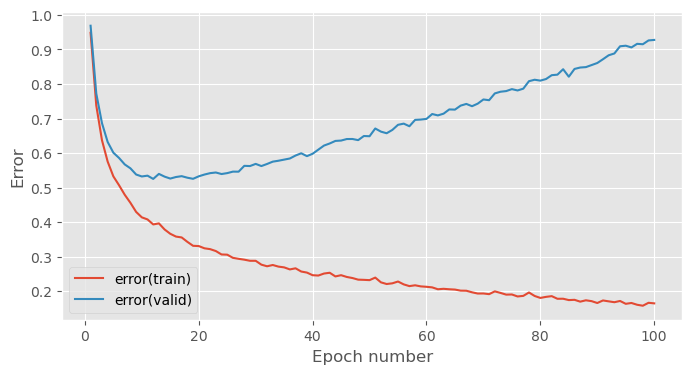

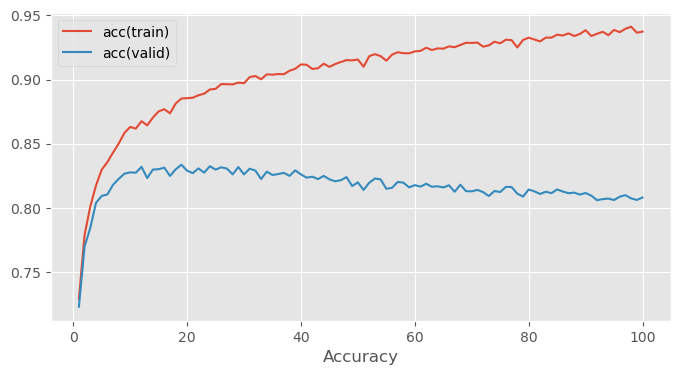

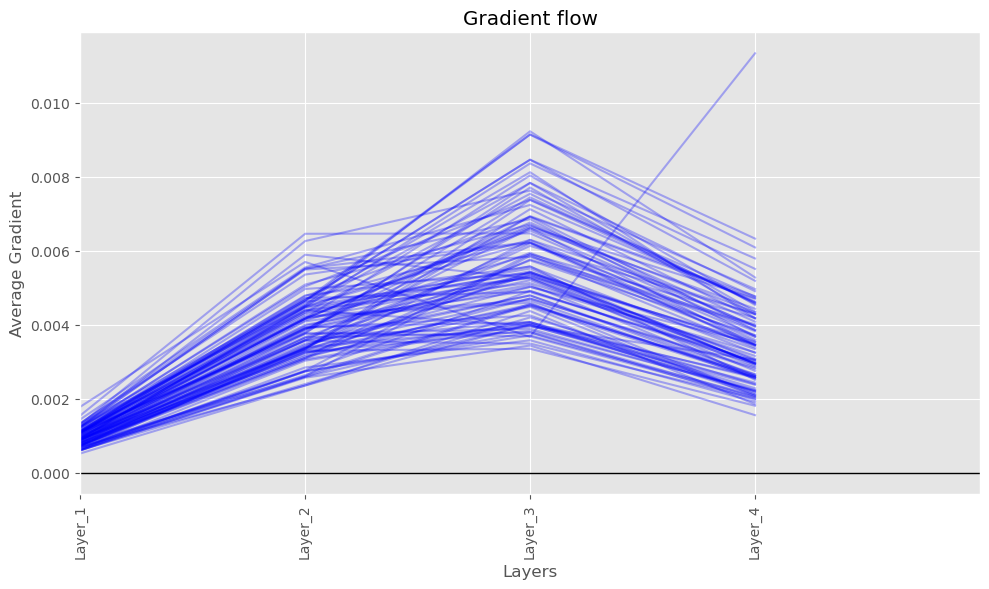

In [15]:
# === Run ONE config and SAVE its curves ===
import numpy as np
import matplotlib.pyplot as plt

# 配置：把 32 改成 64 / 128 再分别跑一次
W = 128                            # ← 宽度
LR = 9e-4
EPOCHS = 100
STATS_INT = 1

# 单隐层模型
model = MultipleLayerModel([
    AffineLayer(784, W,  weights_init, biases_init),
    ReluLayer(),
    AffineLayer(W, 47,   weights_init, biases_init)
])

stats_arr, keys, *_ = train_model_and_plot_stats(
    model, CrossEntropySoftmaxError(), AdamLearningRule(LR),
    train_data, valid_data, EPOCHS, STATS_INT, notebook=True
)

# 1) 存“原始曲线数据”到 .npz（稍后叠图要用）
np.savez(f"width_{W}_stats.npz",
         stats=np.asarray(stats_arr), keys=np.array(keys, dtype=object))

# 2) 也顺手各自保存两张单独图（可选）
# 从 stats_arr+keys 还原字典
def to_dict(stats_arr, keys):
    stats_arr = np.asarray(stats_arr)
    d = {}
    if stats_arr.ndim == 1:
        for i,k in enumerate(keys): d[k] = [float(stats_arr[i])]
    else:
        for i,k in enumerate(keys): d[k] = list(stats_arr[i])
    return d

sd = to_dict(stats_arr, keys)

def pick(name):  # 宽松匹配键名
    t = name.replace(" ","").lower()
    for k in sd:
        if t in k.replace(" ","").lower(): return k
    raise KeyError(name)

acc_tr, acc_v  = sd[pick("acc(train)")],  sd[pick("acc(valid)")]
err_tr, err_v  = sd[pick("error(train)")],sd[pick("error(valid)")]

plt.figure(); plt.plot(acc_tr,label="train"); plt.plot(acc_v,label="valid")
plt.xlabel("Epoch number"); plt.ylabel("Accuracy"); plt.legend()
plt.savefig(f"width_{W}_acc.pdf"); plt.close()

plt.figure(); plt.plot(err_tr,label="train"); plt.plot(err_v,label="valid")
plt.xlabel("Epoch number"); plt.ylabel("Error"); plt.legend()
plt.savefig(f"width_{W}_loss.pdf"); plt.close()

print(f"Saved width_{W}_stats.npz + PDFs")


In [7]:
# 快速体检：看每个宽度存了多少个点，数值范围是否正常
import numpy as np

for w in (32, 64, 128):
    z = np.load(f"width_{w}_stats.npz", allow_pickle=True)
    stats = np.asarray(z["stats"])
    keys  = list(z["keys"]) if np.asarray(z["keys"]).ndim>0 else list(z["keys"].item())

    def get(name_like):
        tgt = name_like.replace(" ","").lower()
        for i,k in enumerate(keys):
            if tgt in k.replace(" ","").lower(): return stats[i]
        raise KeyError(name_like)

    acc_v = get("acc(valid)")
    print(f"width={w}: len(valid_acc)={len(np.atleast_1d(acc_v))}, "
          f"first={np.atleast_1d(acc_v)[0]:.3f}, last={np.atleast_1d(acc_v)[-1]:.3f}")


width=32: len(valid_acc)=4, first=1.001, last=0.706
width=64: len(valid_acc)=4, first=0.821, last=0.753
width=128: len(valid_acc)=4, first=0.637, last=0.785


Saved: width_all_acc.pdf & width_all_loss.pdf


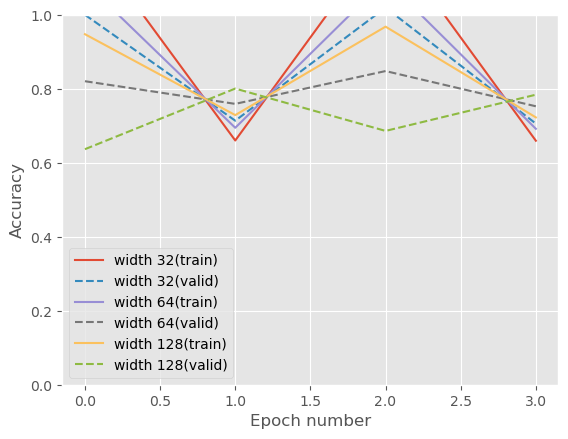

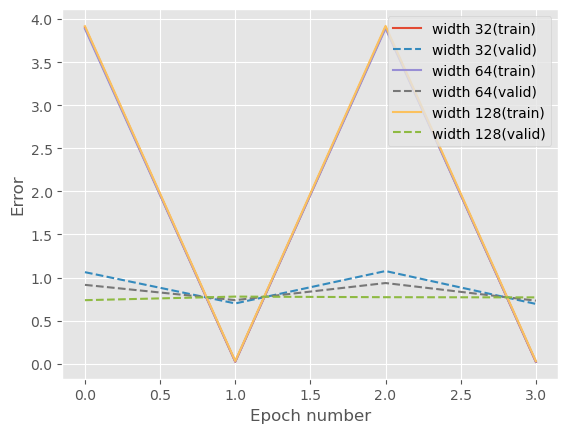

In [6]:
# ==== Make OVERLAY plots for width 32/64/128 from saved .npz ====
import numpy as np
import matplotlib.pyplot as plt
import os

def load_curves(npz_path):
    z = np.load(npz_path, allow_pickle=True)
    stats_arr = np.asarray(z["stats"])

    # --- 解出 keys：兼容 0维(object) / 1维(array) 两种 ---
    raw_keys = z["keys"]
    if isinstance(raw_keys, np.ndarray) and raw_keys.ndim == 0:
        # 0-D object数组，里面包着一个list
        keys = list(raw_keys.item())
    else:
        keys = list(raw_keys)

    # 还原成 {metric_name: list_of_values}
    curves = {}
    if stats_arr.ndim == 1:       # 只有最终值
        for i, k in enumerate(keys):
            curves[k] = [float(stats_arr[i])]
    elif stats_arr.ndim == 2:     # 完整曲线：形如 (n_metrics, n_epochs)
        for i, k in enumerate(keys):
            curves[k] = list(stats_arr[i])
    else:
        raise ValueError(f"Unexpected stats shape: {stats_arr.shape}")
    return curves

def pick_key(d, name_like):
    tgt = name_like.replace(" ", "").lower()
    for k in d:
        if tgt in k.replace(" ", "").lower():
            return k
    raise KeyError(f"Can't find key like {name_like}. Have: {list(d.keys())}")

# ===== 下面照常读取并叠图（示例：宽度 32/64/128）=====
WIDTHS = (32, 64, 128)
curves = {}
for w in WIDTHS:
    fn = f"width_{w}_stats.npz"         # 如果你保存在 runs/width/ 下，这里换成 os.path.join("runs/width", f"width_{w}_stats.npz")
    if not os.path.exists(fn):
        raise FileNotFoundError(f"缺少 {fn}，请先把 W={w} 的单次训练跑完并保存。")
    d = load_curves(fn)
    acc_tr = d[pick_key(d, "acc(train)")]
    acc_v  = d[pick_key(d, "acc(valid)")]
    err_tr = d[pick_key(d, "error(train)")]
    err_v  = d[pick_key(d, "error(valid)")]
    curves[w] = dict(train_acc=acc_tr, valid_acc=acc_v,
                     train_loss=err_tr, valid_loss=err_v)

fig_acc, ax = plt.subplots()
for w in WIDTHS:
    ax.plot(curves[w]["train_acc"], label=f"width {w}(train)")
    ax.plot(curves[w]["valid_acc"], linestyle="--", label=f"width {w}(valid)")
ax.set_xlabel("Epoch number"); ax.set_ylabel("Accuracy"); ax.set_ylim(0,1); ax.legend()
fig_acc.savefig("width_all_acc.pdf")

fig_loss, ax = plt.subplots()
for w in WIDTHS:
    ax.plot(curves[w]["train_loss"], label=f"width {w}(train)")
    ax.plot(curves[w]["valid_loss"], linestyle="--", label=f"width {w}(valid)")
ax.set_xlabel("Epoch number"); ax.set_ylabel("Error"); ax.legend()
fig_loss.savefig("width_all_loss.pdf")

print("Saved: width_all_acc.pdf & width_all_loss.pdf")



## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.8s to complete
    error(train)=3.85e+00, acc(train)=2.14e-02, error(valid)=3.85e+00, acc(valid)=2.09e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.7s to complete
    error(train)=3.85e+00, acc(train)=2.12e-02, error(valid)=3.85e+00, acc(valid)=2.16e-02


...

Epoch 3: 1.7s to complete
    error(train)=3.85e+00, acc(train)=2.11e-02, error(valid)=3.85e+00, acc(valid)=2.13e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 2.3s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.28e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 1.7s to complete
    error(train)=3.85e+00, acc(train)=2.14e-02, error(valid)=3.85e+00, acc(valid)=2.09e-02


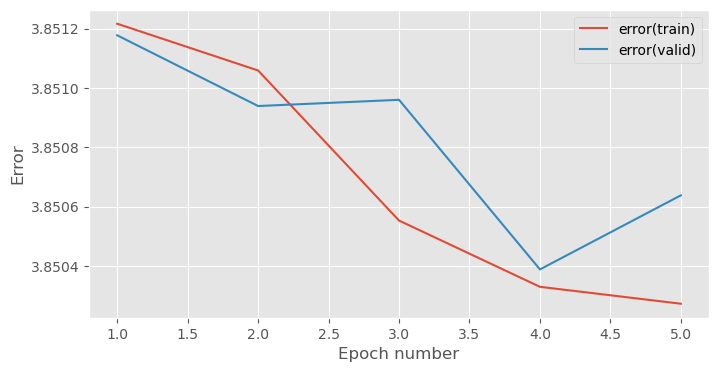

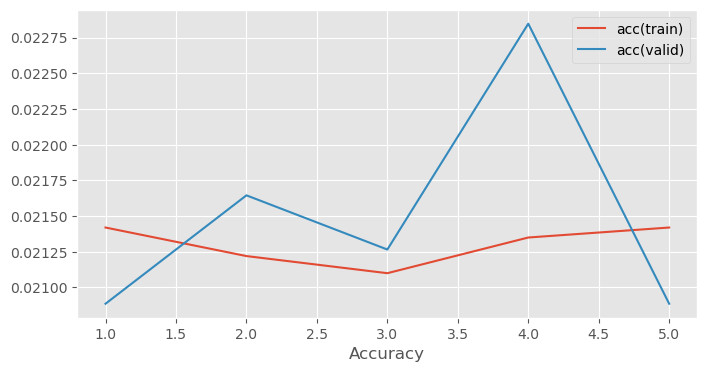

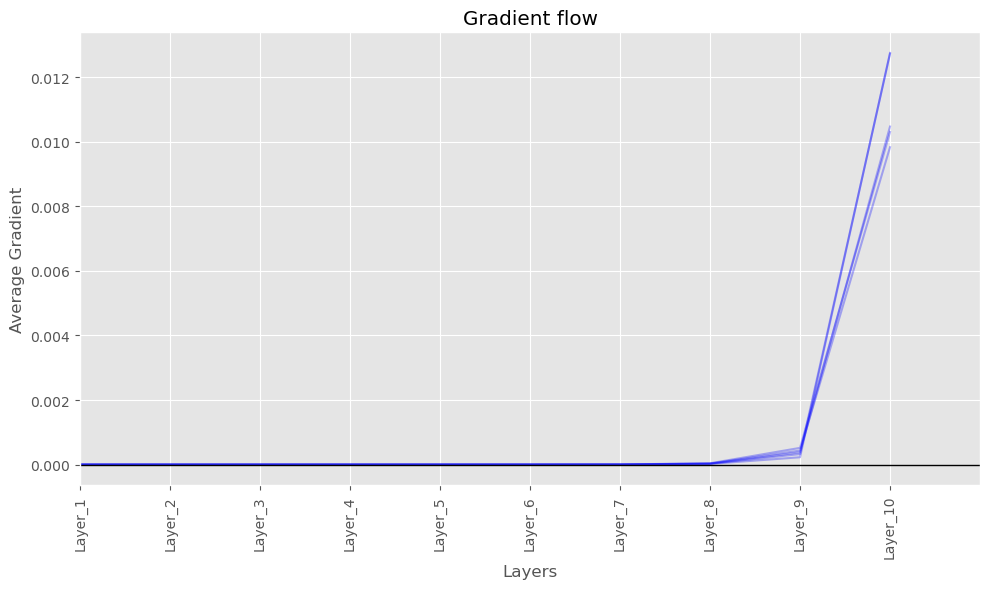

In [7]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [ ]:
# You can then check the plots like this
fig_1 # The training error plot

In [ ]:
fig_2 # The training accuracy plot

In [ ]:
grad_plot # The gradient flow plot